In [1]:
import pandas as pd

df = pd.read_csv("WineQT.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [2]:
df.shape

(1143, 13)

In [3]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='str')

Id column is just a row index, not useful for prediction -> drop
quality is our target, rest are the chemical features

In [4]:
df.drop(['Id'], axis=1, inplace=True)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [7]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(125)

some duplicated rows, dropping them so they don't bias the model

In [9]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [10]:
df['quality'].value_counts()

quality
5    433
6    409
7    122
4     33
8     15
3      6
Name: count, dtype: int64

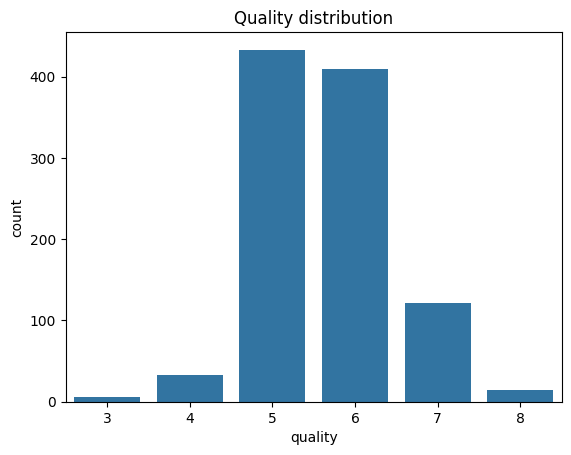

In [11]:
from matplotlib import pyplot as plt
import seaborn as sns

sns.countplot(x="quality", data=df)
plt.title("Quality distribution")
plt.show()

most wines are quality 5 or 6, very few at the extremes (3,4,8)
this is imbalanced, keep it in mind when reading the confusion matrix later

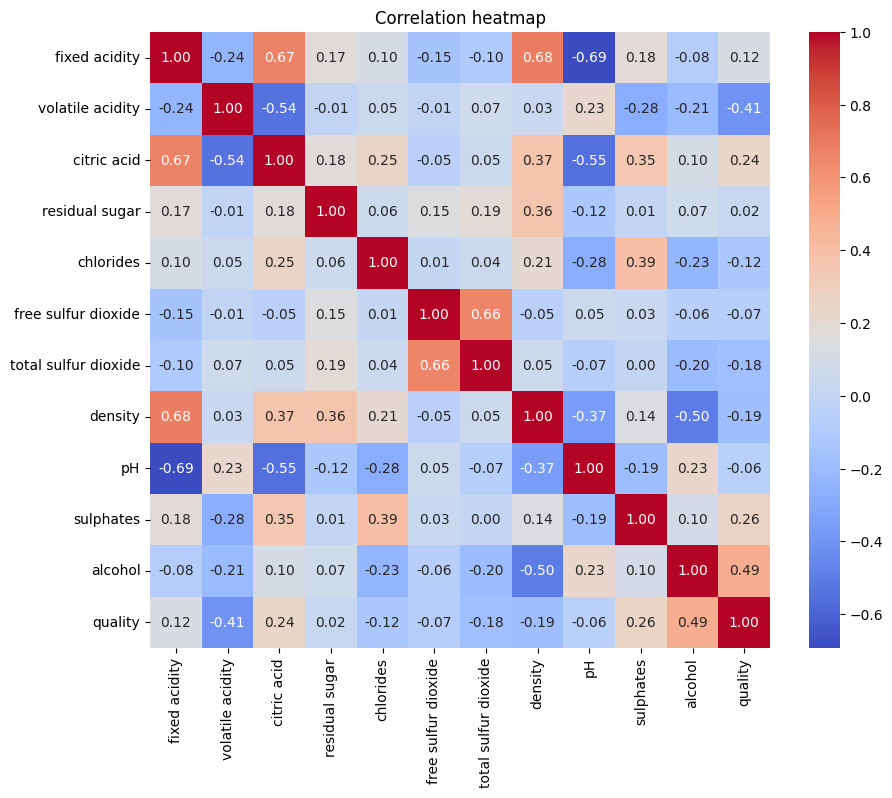

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation heatmap")
plt.show()

alcohol has the strongest positive correlation with quality
volatile acidity has a clear negative correlation with quality
fixed acidity and density/pH are correlated with each other (chemistry makes sense, more acid -> lower pH)

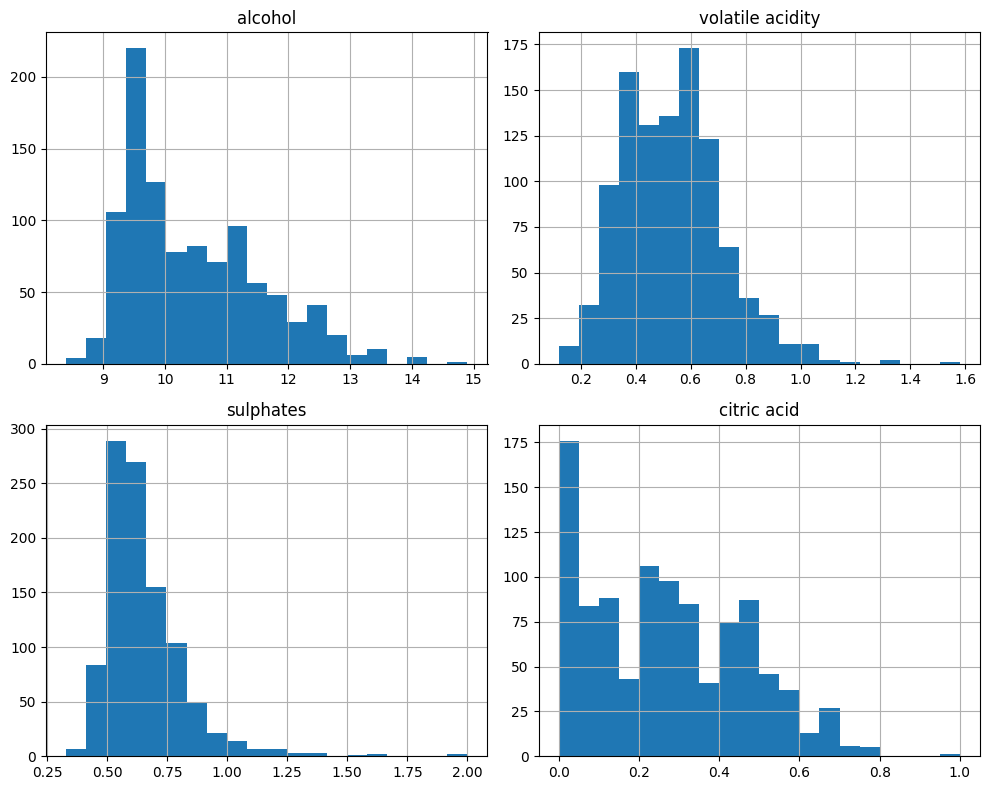

In [13]:
df[['alcohol','volatile acidity','sulphates','citric acid']].hist(figsize=(10,8), bins=20)
plt.tight_layout()
plt.show()

features are all continuous numeric values (unlike the youtube text data before)
so instead of CountVectorizer we go straight into features/target split

In [14]:
x = df.drop('quality', axis=1)
y = df['quality']

In [15]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [16]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((814, 11), (204, 11), (814,), (204,))

GaussianNB assumes each feature is normally distributed within each class
that fits here since all our features are continuous measurements, unlike word counts before

In [17]:
from sklearn.naive_bayes import GaussianNB
NB = GaussianNB()

In [18]:
NB.fit(x_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [19]:
NB.get_params()

{'priors': None, 'var_smoothing': 1e-09}

In [20]:
import numpy as np
NB.class_prior_

array([0.004914  , 0.02579853, 0.42874693, 0.41154791, 0.11916462,
       0.00982801])

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
y_pred = NB.predict(x_test)

<Figure size 800x600 with 0 Axes>

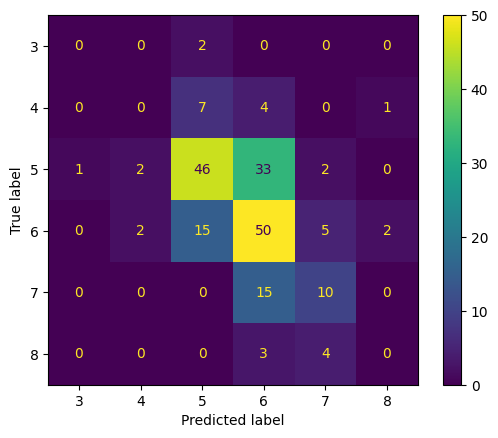

In [22]:
plt.figure(figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [23]:
accuracy_score(y_test, y_pred)

0.5196078431372549

In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        12
           5       0.66      0.55      0.60        84
           6       0.48      0.68      0.56        74
           7       0.48      0.40      0.43        25
           8       0.00      0.00      0.00         7

    accuracy                           0.52       204
   macro avg       0.27      0.27      0.27       204
weighted avg       0.50      0.52      0.50       204



accuracy isn't great, mainly because classes 5 and 6 overlap a lot in the feature space
and the rare classes (3,4,8) barely have samples to learn from

In [25]:
new_sample = pd.DataFrame([
    [7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4],
    [11.2, 0.28, 0.56, 1.9, 0.075, 17.0, 60.0, 0.998, 3.16, 0.58, 9.8],
    [8.1, 0.28, 0.4, 6.9, 0.05, 30.0, 97.0, 0.9951, 3.26, 0.44, 10.1],
], columns=x.columns)
predictions = NB.predict(new_sample)
predictions

array([5, 6, 5])

## Bonus: generating new samples with GaussianNB

GaussianNB stores a mean and variance per feature per class (theta_ and var_).
so we can sample from those distributions ourselves to generate fake wines that "belong" to a chosen quality class

In [26]:
NB.classes_

array([3, 4, 5, 6, 7, 8])

In [27]:
target_class = 6
class_idx = list(NB.classes_).index(target_class)

means = NB.theta_[class_idx]
variances = NB.var_[class_idx]
stds = np.sqrt(variances)

np.random.seed(42)
n_samples = 5
generated = np.random.normal(loc=means, scale=stds, size=(n_samples, len(means)))

generated_df = pd.DataFrame(generated, columns=x.columns)
generated_df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,9.247555,0.487191,0.392701,3.860079,0.075215,13.067623,80.550490,0.998339,3.244560,0.761002,10.204877
1,7.517399,0.549299,-0.114650,0.731100,0.062104,5.960860,48.662123,0.994472,3.094196,0.908668,10.453317
2,8.476020,0.277051,0.156541,2.499695,0.038583,18.633291,25.598868,0.995894,3.223471,0.970517,10.675243
3,6.453213,0.644134,0.022528,2.594049,0.006273,3.082769,45.702950,0.998272,3.346763,0.655709,10.374567
4,5.696734,0.392193,0.173131,3.411237,0.098299,-0.885934,48.910093,0.995679,3.211476,0.772059,11.767203


In [28]:
# sanity check: does the model itself think these belong to the class we generated them for?
NB.predict(generated_df)

array([5, 6, 6, 5, 6])

In [29]:
generated_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,7.478184,0.469974,0.126050,2.619232,0.056095,7.971722,49.884905,0.996531,3.224093,0.813591,10.695041
std,1.444993,0.141589,0.189012,1.198639,0.035256,7.842843,19.685806,0.001708,0.090138,0.125582,0.622759
min,5.696734,0.277051,-0.114650,0.731100,0.006273,-0.885934,25.598868,0.994472,3.094196,0.655709,10.204877
25%,6.453213,0.392193,0.022528,2.499695,0.038583,3.082769,45.702950,0.995679,3.211476,0.761002,10.374567
50%,7.517399,0.487191,0.156541,2.594049,0.062104,5.960860,48.662123,0.995894,3.223471,0.772059,10.453317
75%,8.476020,0.549299,0.173131,3.411237,0.075215,13.067623,48.910093,0.998272,3.244560,0.908668,10.675243
max,9.247555,0.644134,0.392701,3.860079,0.098299,18.633291,80.550490,0.998339,3.346763,0.970517,11.767203


In [30]:
df[df['quality']==target_class][x.columns].describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,409.000000,409.000000,409.000000,409.000000,409.000000,409.000000,409.000000,409.000000,409.000000,409.000000,409.000000
mean,8.328117,0.504731,0.269633,2.444010,0.085687,15.221271,40.097800,0.996597,3.320929,0.674328,10.669030
std,1.782504,0.162929,0.196127,1.227756,0.042584,9.483632,24.635086,0.002004,0.157677,0.154836,1.059796
min,5.000000,0.160000,0.000000,0.900000,0.034000,1.000000,6.000000,0.990070,2.860000,0.400000,8.400000
25%,7.000000,0.380000,0.090000,1.900000,0.068000,7.000000,20.000000,0.995410,3.210000,0.580000,9.800000
50%,7.900000,0.500000,0.260000,2.200000,0.078000,14.000000,35.000000,0.996520,3.320000,0.640000,10.500000
75%,9.300000,0.610000,0.430000,2.500000,0.088000,20.000000,53.000000,0.997900,3.420000,0.740000,11.400000
max,14.300000,1.040000,0.740000,15.400000,0.415000,55.000000,165.000000,1.003690,4.010000,1.950000,14.000000


**Note on the generated data:**

each individual column of the generated samples looks realistic on its own, the means and spread are close to the real quality-6 wines because that's literally where we pulled them from (theta_/var_).

but the samples as a whole aren't fully realistic. GaussianNB assumes every feature is independent given the class, so when it generates it draws each feature separately with no regard to the others. real wine chemistry has features that move together (e.g. fixed acidity vs pH, or density vs alcohol from the correlation heatmap earlier), and the generated rows don't respect that. so some generated rows can combine a high fixed acidity with a high pH at the same time, a combination that's rare/inconsistent in the real data but not extreme enough for a single feature to fail a bounds check.

that's the trade-off with Naive Bayes as a generator: good at reproducing per-feature statistics, bad at reproducing the correlations between features, because "naive" independence is the whole assumption the model is built on.